In [ ]:
pip install --upgrade git+https://github.com/ColibrITD-SAS/landscape_tools@chore--typing-\&-co

# Imports

In [1]:
from landscape_tools import barren_plateaus as bp
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.quantum_info import Statevector
from qiskit.quantum_info import Pauli

/home/gabriel/Desktop/public/landscape_visualisation/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/gabriel/Desktop/public/landscape_visualisation/.venv/lib/python3.12/site-packages/vcs_versioning/_config.py:261: UserWarning: relative_to is expected to be a file, it's the directory /home/gabriel/Desktop/public/landscape_visualisation/.venv/lib/python3.12/site-packages
assuming the parent directory was passed
  return _check_absolute_root(self.root, self.relative_to)


# Example of a problem

## Probability distribution

In [2]:
def get_prob_distribution(params, ansatz, theta_params):

    param_dict = dict(zip(theta_params, params))                                
    # param_dict = {
    #     θ0: 0.5,
    #     θ1: 1.2
    # }

    bound_circuit = ansatz.assign_parameters(param_dict, inplace=False)

    state = Statevector.from_instruction(bound_circuit)
    probs = state.probabilities()

    return np.asarray(probs, dtype=float)

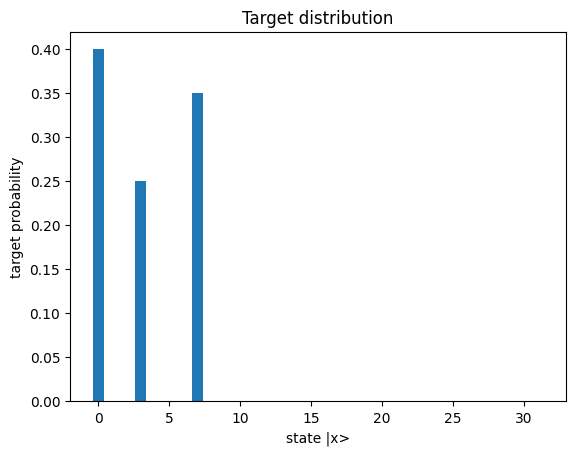

In [3]:
n_qubits = 5
dim = 2 ** n_qubits

p_target = np.zeros(dim)

# index 0 -> |000>, index 1 -> |001>, ..., index 7 -> |111>
p_target[0] = 0.40  # |000>
p_target[3] = 0.25  # |011>
p_target[7] = 0.35  # |111>

p_target = p_target / p_target.sum()    # normalize to ensure probabilities sum to 1

plt.bar(range(dim), p_target)
plt.xlabel("state |x>")
plt.ylabel("target probability")
plt.title("Target distribution")
plt.show()

## Quantum circuit

In [4]:
def build_hea_ansatz(n_qubits, n_layers, Ansatz):
    """
    Hardware Efficient Ansatz :
    - RY + RZ on each qubit
    - CNOT chain
    """
    qc = QuantumCircuit(n_qubits)

    n_params = 2 * n_qubits * n_layers
    theta = ParameterVector("θ", n_params)

    k = 0
    for _ in range(n_layers):
        for q in range(n_qubits):
            qc.ry(theta[k], q)
            k += 1
            qc.rz(theta[k], q)
            k += 1

        for q in range(n_qubits - 1):
            qc.cx(q, q + 1)

    qc.metadata = {"parameters": theta, "ansatz_name": Ansatz,}

    return qc

In [5]:
def generate_params_hea(n_qubits, n_layers):
    """
    Generate random parameters for HEA ansatz (uniform distribution).
    """

    n_params = 2 * n_qubits * n_layers
    params = np.random.uniform(0, 2 * np.pi, n_params)

    return params

Number of parameters: 20


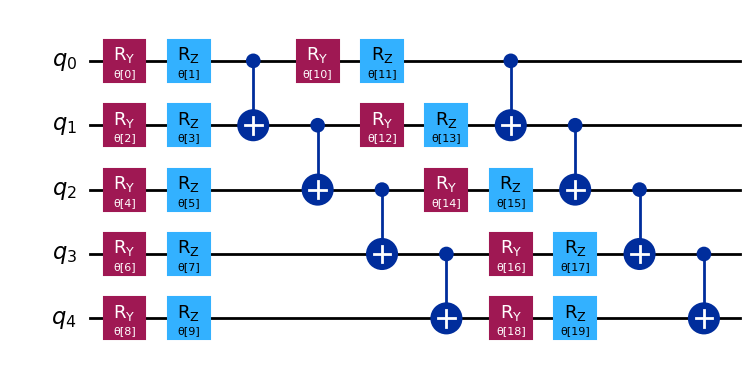

In [6]:
n_layers = 2

ansatz = build_hea_ansatz(n_qubits, n_layers, "HEA_test")
theta_params = ansatz.metadata["parameters"]

n_params = len(theta_params)

print("Number of parameters:", n_params)
ansatz.draw("mpl")

## Loss function

In [7]:
def mse_loss(params, ansatz, theta_params, p_target):
    p_model = get_prob_distribution(params, ansatz, theta_params)
    return np.sum((p_model - p_target) ** 2)

In [8]:
def circuit_mse_loss_builder(
    context,
    target="uniform",
):
    from qiskit.quantum_info import Statevector

    circuit = context["circuits"]
    n_qubits = context["n_qubits"]

    if circuit.metadata is not None and "parameters" in circuit.metadata:
        parameters = circuit.metadata["parameters"]
    else:
        parameters = list(circuit.parameters)

    dim = 2 ** n_qubits

    if target == "zero":
        p_target = np.zeros(dim)
        p_target[0] = 1.0

    elif target == "uniform":
        p_target = np.ones(dim) / dim

    else:
        raise ValueError("target must be either 'zero' or 'uniform'.")

    def loss(theta):
        theta = np.asarray(theta, dtype=float)

        bound_circuit = circuit.assign_parameters(
            dict(zip(parameters, theta)),
            inplace=False,
        )

        probs = Statevector.from_instruction(bound_circuit).probabilities()

        value = np.sum((probs - p_target) ** 2)

        return float(value)

    return loss

# Barren Plateaus Analysis

In [12]:
experiment1 = bp.ExperimentConfig(
    analysis_type="layerwise_qubits_padding",
    N_qubits=[2,4,6,8],
    N_layers=[5,8],
    ansatz_name="HEA_test",
    initial_Pauli_string=None, #Pauli('IZ'),
    padding_types=["I","linear_half"],
)

experiment2 = bp.ExperimentConfig(
    analysis_type="joint_scaling_padding",
    N_qubits=[2,4,6,8],
    N_layers=[2,4,8],
    ansatz_name="HEA_test",
    initial_Pauli_string=Pauli('IZ'),
    padding_types=["log"],
)

sampling = bp.SamplingConfig(
    bootstrap_B=500,
    rel_err_target=0.05,
    N_max=20000,
)

execution = bp.ExecutionConfig(
    verbose=True,
    n_jobs=8
)

In [13]:
result1 = bp.barren_plateaus_analysis(
    experiment=experiment1,
    cost_function_builder=circuit_mse_loss_builder,
    generate_params=generate_params_hea,
    generate_circuits=build_hea_ansatz,
    sampling=sampling,
    execution=execution,
)

ValueError: analysis_type='layerwise_qubits_padding' requires initial_Pauli_string.

--------------------
Number of qubits: 2
Number of layers: 2
Padding type: log
Pauli string: IZ


[Adaptive sampling] N = 900 | relative error = 5.67%
[Adaptive sampling] Adding 490 samples (N: 900 -> 1390)


[Adaptive sampling] N = 1390 | relative error = 4.68%
[Adaptive sampling] Target reached with N_samples = 1390 (relative error target reached)
var = 0.019599396694613407
--------------------
Number of qubits: 4
Number of layers: 4
Padding type: log
Pauli string: IZIZ


[Adaptive sampling] N = 900 | relative error = 11.16%
[Adaptive sampling] Adding 4480 samples (N: 900 -> 5380)


[Adaptive sampling] N = 5380 | relative error = 4.13%
[Adaptive sampling] Target reached with N_samples = 5380 (relative error target reached)
var = 0.0011617593890392362
--------------------
Number of qubits: 6
Number of layers: 8
Padding type: log
Pauli string: IIZZIZ


[Adaptive sampling] N = 900 | relative error = 9.20%
[Adaptive sampling] Adding 2757 samples (N: 900 -> 3657)


[Adaptive sampling] N = 3657 | relative error = 4.01%
[Adaptive sampling] Target reached with N_samples = 3657 (relative error target reached)
var = 1.6652759967862243e-05
--------------------
Number of qubits: 8
Number of layers: 8
Padding type: log
Pauli string: IIIIZZIZ


[Adaptive sampling] N = 900 | relative error = 6.39%
[Adaptive sampling] Adding 864 samples (N: 900 -> 1764)


[Adaptive sampling] N = 1764 | relative error = 4.89%
[Adaptive sampling] Target reached with N_samples = 1764 (relative error target reached)
var = 4.6567562095362613e-07


FileNotFoundError: [Errno 2] No such file or directory: 'figures/joint_scaling_padding.pdf'

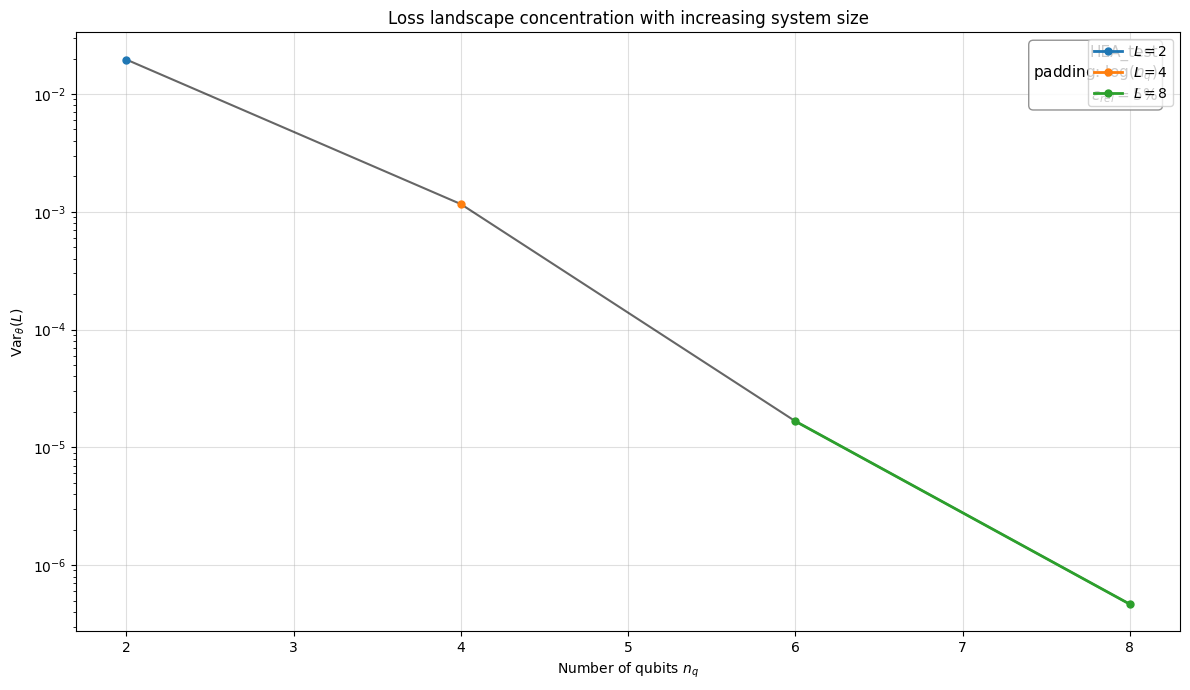

In [11]:
result2 = bp.barren_plateaus_analysis(
    experiment=experiment2,
    cost_function_builder=circuit_mse_loss_builder,
    generate_params=generate_params_hea,
    generate_circuits=build_hea_ansatz,
    sampling=sampling,
    execution=execution,
)